## DSGRN Boolean Code Usage

Install DSGRN with

In [1]:
# !pip install DSGRN

### Defining a Regulatory Network

In [2]:
import DSGRN
import time

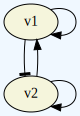

In [3]:
net_spec = """v1 : v1 + v2  : M
              v2 : ~v1 + v2 : M"""

network = DSGRN.Network(net_spec)

DSGRN.DrawGraph(network)

In [4]:
parameter_graph = DSGRN.ParameterGraph(network)

print(parameter_graph.size())

1600


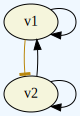

In [5]:
net_spec = """v1 : v1 + v2
              v2 : (~v1)(v2)"""

network = DSGRN.Network(net_spec)

DSGRN.DrawGraph(network)

In [6]:
parameter_graph = DSGRN.ParameterGraph(network)

print(parameter_graph.size())

1600


In [7]:
net_spec = """v1 : v1 + v2  : B
              v2 : ~v1 + v2 : B"""

network = DSGRN.Network(net_spec)

parameter_graph = DSGRN.ParameterGraph(network)

print(parameter_graph.size())

144


In [8]:
net_spec = """v1 : v1 + v2  : M E
              v2 : ~v1 + v2 : M E"""

network = DSGRN.Network(net_spec)

parameter_graph = DSGRN.ParameterGraph(network)

print(parameter_graph.size())

196


### Plotting the parameter graph

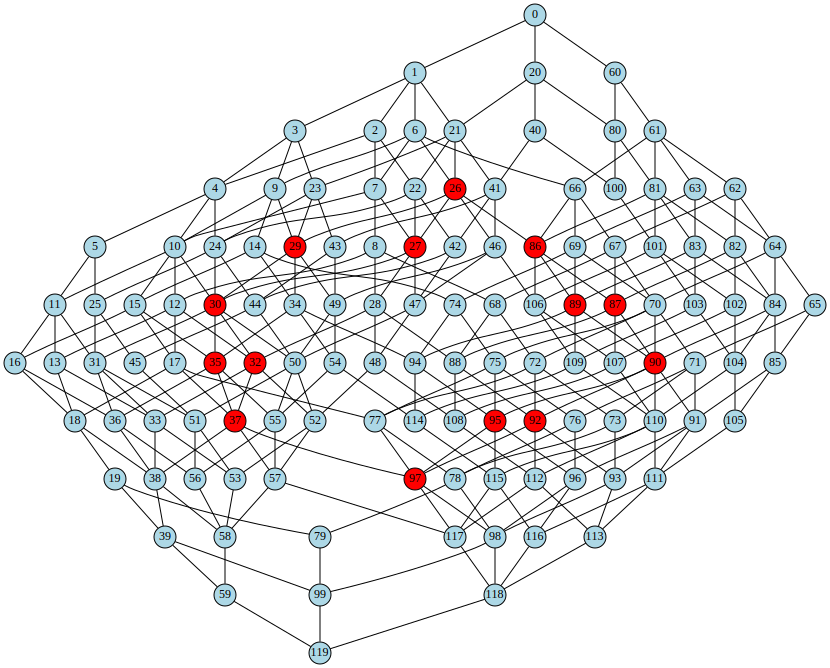

In [9]:
net_spec = """v1 : v1 + v2
              v2 : ~v1"""

network = DSGRN.Network(net_spec)

parameter_graph = DSGRN.ParameterGraph(network)

DSGRN.draw_parameter_graph(parameter_graph)

### Defining a parameter

In [10]:
net_spec = """v1 : v1 + v2  : M
              v2 : ~v1 + v2 : M"""

network = DSGRN.Network(net_spec)

parameter_graph = DSGRN.ParameterGraph(network)

In [11]:
par_index = 1032

parameter = parameter_graph.parameter(par_index)

In [12]:
print(parameter.partialorders())

v1 : (p0, t0, p2, t1, p1, p3)
v2 : (t1, p0, p1, p2, t0, p3)


### Getting a parameter index from partial orders

In [13]:
partial_orders = ['(p0, t0, p2, t1, p1, p3)',
                  '(t1, p0, p1, p2, t0, p3)']

par_index = DSGRN.index_from_partial_orders(parameter_graph, partial_orders)

print(par_index)

1032


### Parameter graph sizes

In [14]:
net_spec = """v1 : v1 + v2 + ~v3
              v2 : ~v1
              v3 : v1 + v2"""

network = DSGRN.Network(net_spec)

parameter_graph = DSGRN.ParameterGraph(network)

print(parameter_graph.size())

305424


In [15]:
net_spec = """v1 : (v1 + v2)(~v3)
              v2 : ~v1
              v3 : v1 + v2"""

network = DSGRN.Network(net_spec)

parameter_graph = DSGRN.ParameterGraph(network)

print(parameter_graph.size())

326592


In [16]:
net_spec = """v1 : v1 + v2 + ~v3 : M
              v2 : ~v1           : M
              v3 : v1 + v2       : M"""

network = DSGRN.Network(net_spec)

parameter_graph = DSGRN.ParameterGraph(network)

print(parameter_graph.size())

383184


In [17]:
net_spec = """v1 : (v1 + v2)(~v3) : M
              v2 : ~v1            : M
              v3 : v1 + v2        : M"""

network = DSGRN.Network(net_spec)

parameter_graph = DSGRN.ParameterGraph(network)

print(parameter_graph.size())

383184


### Computing dynamics

In [18]:
net_spec = """v1 : v1 + v2  : M
              v2 : ~v1 + v2 : M"""

network = DSGRN.Network(net_spec)

parameter_graph = DSGRN.ParameterGraph(network)

In [19]:
par_index = 926

parameter = parameter_graph.parameter(par_index)

In [20]:
%%time
morse_graph, stg, graded_complex = DSGRN.Blowup.ConleyMorseGraph(parameter)

CPU times: user 9.7 ms, sys: 1.04 ms, total: 10.7 ms
Wall time: 10.4 ms


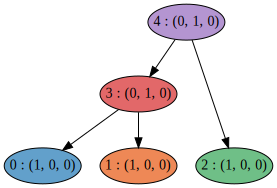

In [21]:
DSGRN.Blowup.PlotMorseGraph(morse_graph)

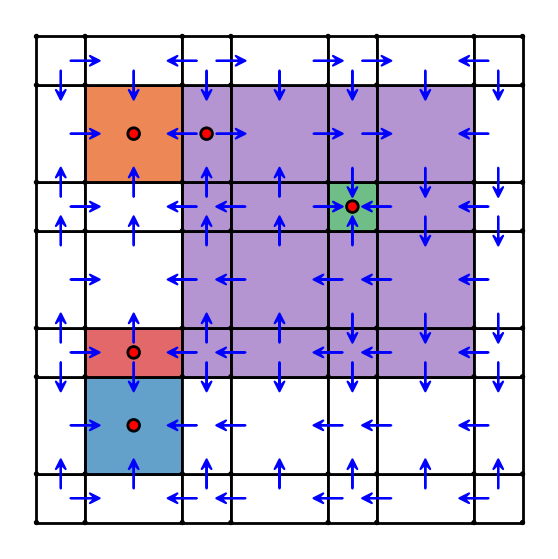

In [22]:
DSGRN.Blowup.PlotMorseSets(morse_graph, stg, graded_complex)

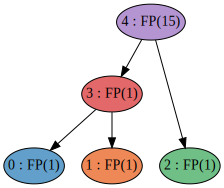

In [23]:
DSGRN.Blowup.PlotMorseGraph(morse_graph, label='a')